In [1]:
import os

from ddpg_per import DDPG
from envs import TradingEnv

I0000 00:00:1777043337.231195  276540 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777043337.296503  276540 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777043338.794274  276540 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/mi

Num GPUs Available: 0


E0000 00:00:1777043340.408741  276540 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
BASELINE_SABR = {
    "mu": 0.05,
    "vol": 0.20,
    "volvol": 0.60,
    "beta": 1.0,
    "rho": -0.4,
}


# Learning stability accross checkpoints

## Weights

Loading baseline_daily1
1. generate asset price paths (sabr)
2. generate BS price, BS delta, and Bartlett delta
simulation done!


/home/onyxia/rl-hedge-2019/ddpg_env/lib/python3.13/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/home/onyxia/rl-hedge-2019/utils.py:135: RuntimeWarning: invalid value encountered in divide
  SABRIV = np.where(F == K, vol * B / (F ** (1 - beta)), A * B * Phi / Chi)
/home/onyxia/rl-hedge-2019/utils.py:155: RuntimeWarning: divide by zero encountered in divide
  d1 = (np.log(S / K) + (r - q + iv * iv / 2) * T) / (iv * np.sqrt(T))


Loading baseline_daily2
1. generate asset price paths (sabr)
2. generate BS price, BS delta, and Bartlett delta
simulation done!
Loading baseline_daily3
1. generate asset price paths (sabr)
2. generate BS price, BS delta, and Bartlett delta
simulation done!
Loading baseline_daily4
1. generate asset price paths (sabr)
2. generate BS price, BS delta, and Bartlett delta
simulation done!
Loading baseline_daily5
1. generate asset price paths (sabr)
2. generate BS price, BS delta, and Bartlett delta
simulation done!
Loading baseline_daily6
1. generate asset price paths (sabr)
2. generate BS price, BS delta, and Bartlett delta
simulation done!
Loading baseline_daily7
1. generate asset price paths (sabr)
2. generate BS price, BS delta, and Bartlett delta
simulation done!
Loading baseline_daily8
1. generate asset price paths (sabr)
2. generate BS price, BS delta, and Bartlett delta
simulation done!
Loading baseline_daily9
1. generate asset price paths (sabr)
2. generate BS price, BS delta, and 

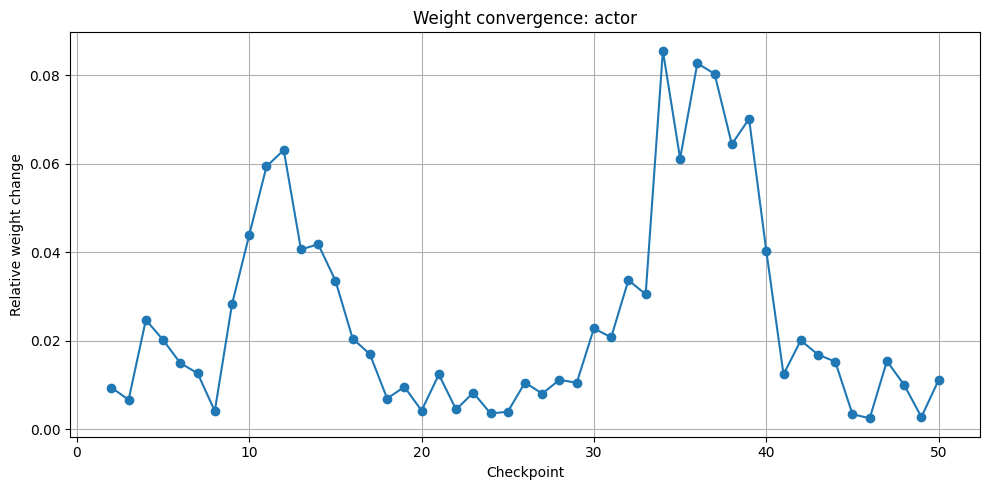

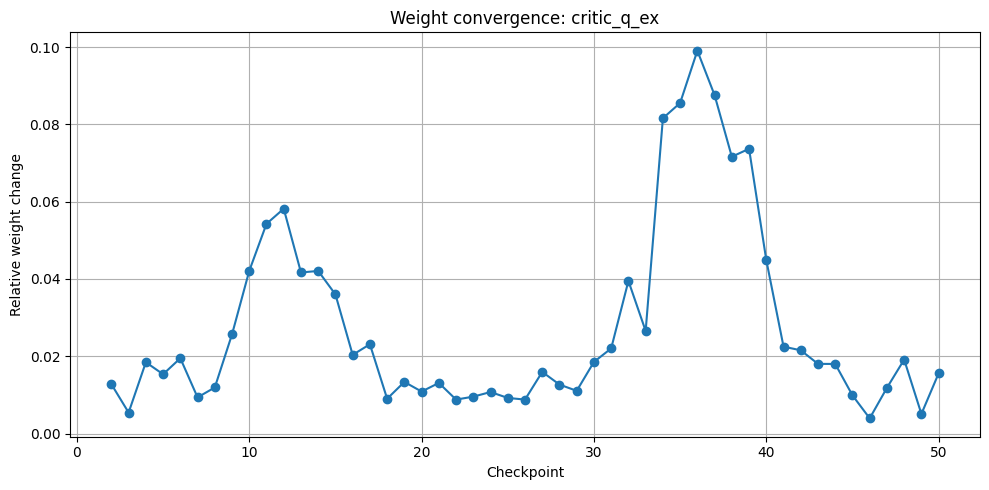

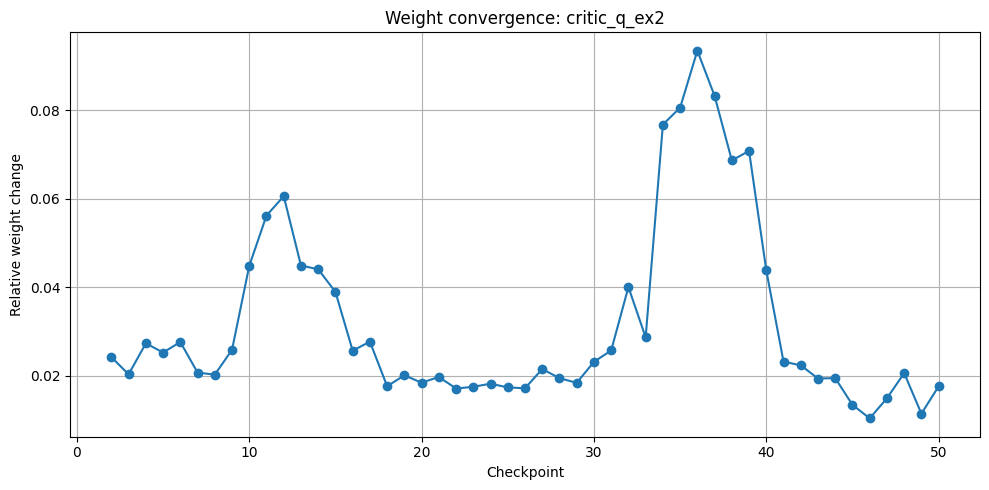

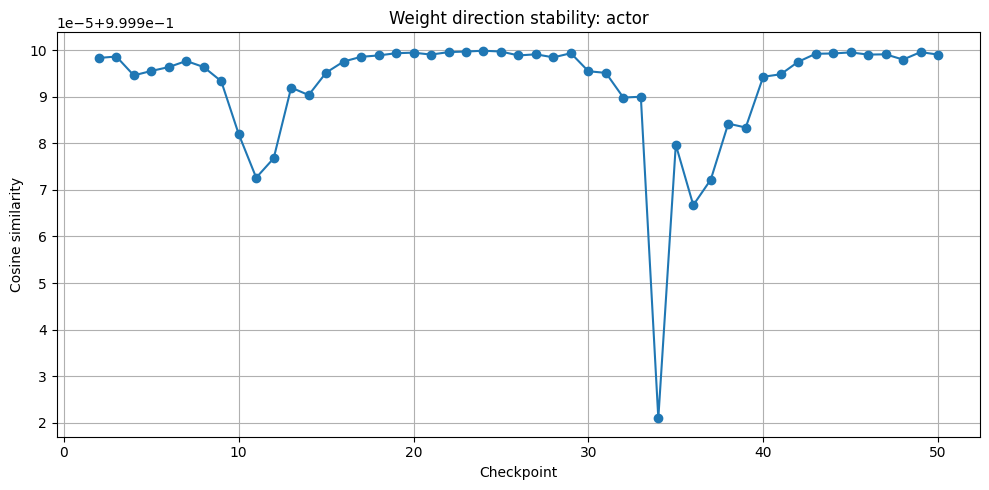

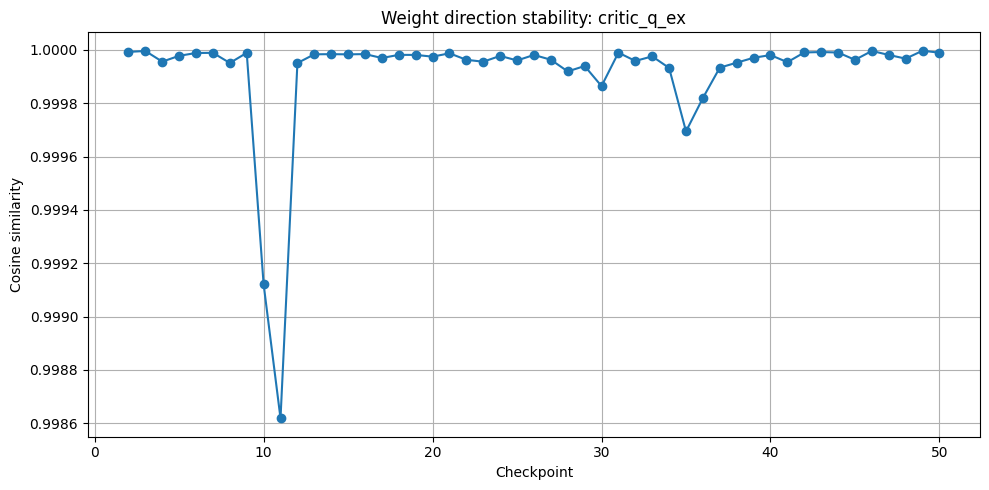

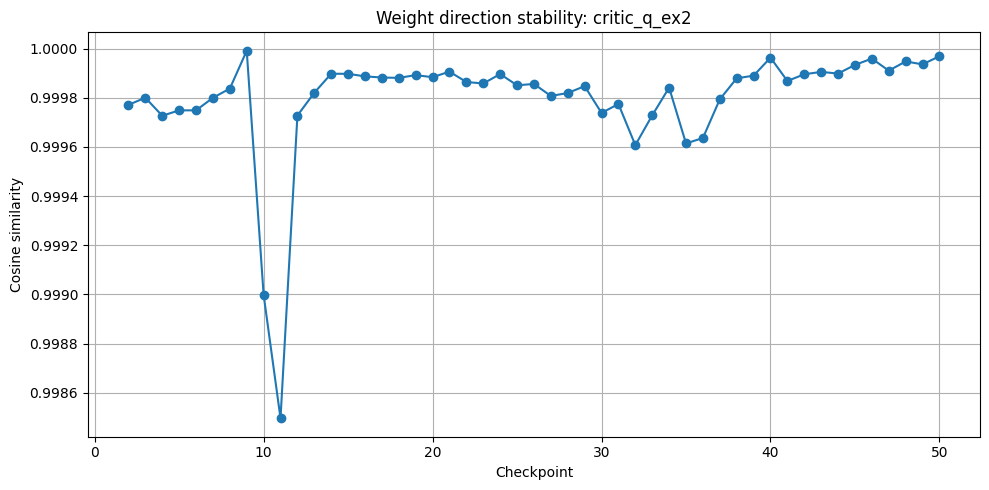

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ddpg_per import DDPG
from envs import TradingEnv


def make_agent():
    env = TradingEnv(
        continuous_action_flag=True,
        sabr_flag=True,
        dg_random_seed=42,
        init_ttm=20,
        trade_freq=1,
        spread=0.01,
        num_contract=1,
        num_sim=1000,
        model_params=BASELINE_SABR,
    )
    return DDPG(env)


def flat_weights(model):
    return np.concatenate([w.reshape(-1) for w in model.get_weights()])


def load_checkpoint(tag):
    agent = make_agent()
    agent.load(tag=tag)
    return agent


def weight_stats(w_prev, w_curr):
    diff = w_curr - w_prev

    norm_prev = np.linalg.norm(w_prev)
    norm_curr = np.linalg.norm(w_curr)
    norm_diff = np.linalg.norm(diff)

    rel_diff = norm_diff / (norm_prev + 1e-12)

    cosine = np.dot(w_prev, w_curr) / (
        np.linalg.norm(w_prev) * np.linalg.norm(w_curr) + 1e-12
    )

    return norm_prev, norm_curr, norm_diff, rel_diff, cosine


checkpoint_tags = [f"baseline_daily{i}" for i in range(1, 51)]

rows = []
prev_agent = None
prev_tag = None

for tag in checkpoint_tags:
    print("Loading", tag)
    agent = load_checkpoint(tag)

    if prev_agent is not None:
        for model_name, model_prev, model_curr in [
            ("actor", prev_agent.actor, agent.actor),
            ("critic_q_ex", prev_agent.critic_q_ex, agent.critic_q_ex),
            ("critic_q_ex2", prev_agent.critic_q_ex2, agent.critic_q_ex2),
        ]:
            w_prev = flat_weights(model_prev)
            w_curr = flat_weights(model_curr)

            norm_prev, norm_curr, norm_diff, rel_diff, cosine = weight_stats(
                w_prev, w_curr
            )

            rows.append({
                "from_checkpoint": prev_tag,
                "to_checkpoint": tag,
                "model": model_name,
                "norm_prev": norm_prev,
                "norm_curr": norm_curr,
                "norm_diff": norm_diff,
                "relative_diff": rel_diff,
                "cosine_similarity": cosine,
            })

    prev_agent = agent
    prev_tag = tag


df = pd.DataFrame(rows)
print(df)

df.to_csv("weight_convergence_baseline_daily.csv", index=False)


for model_name in df["model"].unique():
    sub = df[df["model"] == model_name]

    plt.figure(figsize=(10, 5))
    plt.plot(range(2, 51), sub["relative_diff"], marker="o")
    plt.xlabel("Checkpoint")
    plt.ylabel("Relative weight change")
    plt.title(f"Weight convergence: {model_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


for model_name in df["model"].unique():
    sub = df[df["model"] == model_name]

    plt.figure(figsize=(10, 5))
    plt.plot(range(2, 51), sub["cosine_similarity"], marker="o")
    plt.xlabel("Checkpoint")
    plt.ylabel("Cosine similarity")
    plt.title(f"Weight direction stability: {model_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Hedging cost

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ddpg_per import DDPG
from envs import TradingEnv


BASELINE_SABR = {
    "mu": 0.05,
    "vol": 0.20,
    "volvol": 0.60,
    "beta": 1.0,
    "rho": -0.4,
}


def make_env(n_episodes=2000):
    return TradingEnv(
        continuous_action_flag=True,
        sabr_flag=True,
        dg_random_seed=123,
        init_ttm=20,
        trade_freq=1,
        spread=0.01,
        num_contract=1,
        num_sim=n_episodes,
        model_params=BASELINE_SABR,
    )


def compute_avg_cost(tag, n_episodes=2000):
    env = make_env(n_episodes)
    agent = DDPG(env)
    agent.load(tag=tag)
    agent.epsilon = -1.0  # no exploration

    total_cost = 0.0

    for ep in range(n_episodes):
        obs = env.reset()
        done = False

        while not done:
            current_price = env.state[0]
            current_position = env.state[1]

            x = np.array(obs).reshape(1, -1)
            action, _, _ = agent.egreedy_action(x)
            action = float(np.asarray(action).reshape(-1)[0])

            trade_size = action - float(current_position)
            cost = abs(trade_size) * current_price * env.spread

            obs, reward, done, _ = env.step(action)

            total_cost += cost

    return total_cost / n_episodes

In [ ]:
costs = []

checkpoints = list(range(1, 51))

for k in checkpoints:
    tag = f"baseline_daily{k}"  # matches your filenames
    print(f"Computing cost for checkpoint {k}...")

    avg_cost = compute_avg_cost(tag, n_episodes=1000)
    costs.append(avg_cost)

df_cost_vs_training = pd.DataFrame({
    "checkpoint": checkpoints,
    "avg_cost": costs
})

df_cost_vs_training.to_csv("analysis/cost_vs_training.csv", index=False)

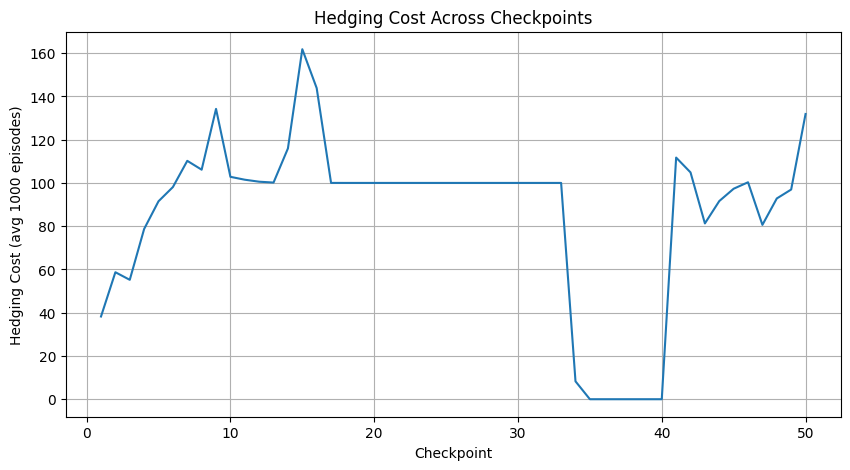

In [9]:
plt.figure(figsize=(10,5))
plt.plot(df_cost_vs_training["checkpoint"], df_cost_vs_training["avg_cost"])
plt.xlabel("Checkpoint")
plt.ylabel("Hedging Cost (avg 1000 episodes)")
plt.title("Hedging Cost Across Checkpoints")
plt.grid(True)
plt.show()

In [5]:
os.makedirs("analysis", exist_ok=True)

df_cost_vs_training.to_csv("analysis/cost_vs_training.csv", index=False)

# Rigourous testing

## Baseline in and out of distribution

In [ ]:
import os
import numpy as np
import pandas as pd
from multiprocessing import Pool, cpu_count

from ddpg_per import DDPG
from envs import TradingEnv


BASELINE_SABR = {
    "mu": 0.05,
    "vol": 0.20,
    "volvol": 0.60,
    "beta": 1.0,
    "rho": -0.4,
}

HIGH_VOL_SABR = {
    "mu": 0.05,
    "vol": 0.30,
    "volvol": 0.60,
    "beta": 1.0,
    "rho": -0.4,
}

FINAL_TAG = "baseline_daily50"
N_EPISODES = 100_000
N_WORKERS = cpu_count()
CHUNK_SIZE = 2_000


def make_env(model_params, n_episodes, seed):
    return TradingEnv(
        continuous_action_flag=True,
        sabr_flag=True,
        dg_random_seed=seed,
        init_ttm=20,
        trade_freq=1,
        spread=0.01,
        num_contract=1,
        num_sim=n_episodes,
        model_params=model_params,
    )


def evaluate_chunk(args):
    method, tag, model_params, scenario, n_episodes, seed = args

    env = make_env(model_params, n_episodes, seed)

    agent = DDPG(env)
    agent.epsilon = -1.0

    if method == "rl":
        agent.load(tag=tag)

    costs = []

    for i in range(n_episodes):
        obs = env.reset()
        done = False
        episode_reward = 0.0

        while not done:
            if method == "rl":
                x = np.asarray(obs).reshape(1, -1)
                action, _, _ = agent.egreedy_action(x)
                action = float(np.asarray(action).reshape(-1)[0])

            elif method == "delta":
                action = (
                    env.delta_path[i % env.num_path, env.t]
                    * env.num_contract
                    * 100
                )

            elif method == "bartlett":
                action = (
                    env.bartlett_delta_path[i % env.num_path, env.t]
                    * env.num_contract
                    * 100
                )

            else:
                raise ValueError(f"Unknown method: {method}")

            obs, reward, done, _ = env.step(action)
            episode_reward += float(reward)

        costs.append(-episode_reward)

    return costs


def evaluate_parallel(method, tag, model_params, scenario):
    tasks = []
    remaining = N_EPISODES
    seed = 123

    while remaining > 0:
        print(remaining)
        n = min(CHUNK_SIZE, remaining)
        tasks.append((method, tag, model_params, scenario, n, seed))
        remaining -= n
        seed += 1

    results = []

    with Pool(N_WORKERS) as pool:
        for j, chunk in enumerate(pool.imap_unordered(evaluate_chunk, tasks), 1):
            results.append(chunk)
            done = min(j * CHUNK_SIZE, N_EPISODES)
            print(f"{scenario} | {method}: Finished {done}/{N_EPISODES}")

    all_costs = [c for chunk in results for c in chunk]

    return pd.DataFrame({
        "scenario": scenario,
        "method": method,
        "episode": range(len(all_costs)),
        "final_cost": all_costs,
    })


if __name__ == "__main__":

    dfs = []

    for scenario, params in [
        ("baseline", BASELINE_SABR),
        ("high_vol", HIGH_VOL_SABR),
    ]:
        for method in ["rl", "delta", "bartlett"]:
            df_method = evaluate_parallel(
                method=method,
                tag=FINAL_TAG,
                model_params=params,
                scenario=scenario,
            )
            dfs.append(df_method)

    df = pd.concat(dfs, ignore_index=True)

    df["is_valid"] = np.isfinite(df["final_cost"])

    df.to_csv("analysis/final_costs_rl_delta_bartlett_100k_raw.csv", index=False)

    df_valid = df[df["is_valid"]].copy()
    df_valid.to_csv("analysis/final_costs_rl_delta_bartlett_100k_valid.csv", index=False)


In [12]:
# Option price SABR 

from scipy.stats import norm

def bs_price(S, K, T, r, sigma):
    eps = 1e-8
    T = max(T, eps)
    sigma = max(sigma, eps)

    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    return S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)


def sabr_price(S, K, T, r, alpha, beta, rho, nu):
    # very simplified Hagan ATM-like approximation
    eps = 1e-8
    F = S

    if abs(F - K) < eps:
        sigma = alpha / (F**(1 - beta))
    else:
        z = (nu / alpha) * (F*K)**((1-beta)/2) * np.log(F/K)
        x_z = np.log((np.sqrt(1 - 2*rho*z + z*z) + z - rho)/(1 - rho))
        sigma = alpha * z / x_z

    sigma = max(sigma, 1e-6)

    return bs_price(S, K, T, r, sigma)

In [16]:
df_valid.columns

Index(['scenario', 'method', 'episode', 'final_cost', 'is_valid',
       'option_price'],
      dtype='str')

In [18]:
df_valid['option_price'] = np.where(df_valid['scenario'] == 'baseline', 
                                    sabr_price(100, 100, 20/200, 0, BASELINE_SABR['vol'], BASELINE_SABR['beta'], BASELINE_SABR['rho'], BASELINE_SABR['volvol']), 
                                    sabr_price(100, 100, 20/200, 0, HIGH_VOL_SABR['vol'], HIGH_VOL_SABR['beta'], HIGH_VOL_SABR['rho'], HIGH_VOL_SABR['volvol']))

df_valid['rel_cost'] = (df_valid['final_cost'] - df_valid['option_price']) / df_valid['option_price']
summary = df_valid.groupby(["scenario", "method"])["rel_cost"].agg(
    ["mean", "std", "median", "count"]
)
summary

mean         std     median   count
scenario method                                            
baseline bartlett  95.106197   98.634516  78.397906  100000
         delta     95.383033   98.387513  78.595684  100000
         rl        78.044771  124.390923  73.447902  100000
high_vol bartlett  63.018929   96.940633  44.701816  100000
         delta     63.207338   96.728200  44.893092  100000
         rl        51.662993  124.304643  46.559937  100000

## Domain randomization low and high vol

In [ ]:
import os
import numpy as np
import pandas as pd
from multiprocessing import Pool, cpu_count

from ddpg_per import DDPG
from envs import TradingEnv


BASELINE_SABR = {
    "mu": 0.05,
    "vol": 0.20,
    "volvol": 0.60,
    "beta": 1.0,
    "rho": -0.4,
}

HIGH_VOL_SABR = {
    "mu": 0.05,
    "vol": 0.30,
    "volvol": 0.60,
    "beta": 1.0,
    "rho": -0.4,
}

FINAL_TAG = "domain_randomized_daily50"
N_EPISODES = 100_000
N_WORKERS = cpu_count()
CHUNK_SIZE = 2_000


def make_env(model_params, n_episodes, seed):
    return TradingEnv(
        continuous_action_flag=True,
        sabr_flag=True,
        dg_random_seed=seed,
        init_ttm=20,
        trade_freq=1,
        spread=0.01,
        num_contract=1,
        num_sim=n_episodes,
        model_params=model_params,
    )


def evaluate_chunk(args):
    method, tag, model_params, scenario, n_episodes, seed = args

    env = make_env(model_params, n_episodes, seed)

    agent = DDPG(env)
    agent.epsilon = -1.0

    if method == "rl":
        agent.load(tag=tag)

    costs = []

    for i in range(n_episodes):
        obs = env.reset()
        done = False
        episode_reward = 0.0

        while not done:
            if method == "rl":
                x = np.asarray(obs).reshape(1, -1)
                action, _, _ = agent.egreedy_action(x)
                action = float(np.asarray(action).reshape(-1)[0])

            elif method == "delta":
                action = (
                    env.delta_path[i % env.num_path, env.t]
                    * env.num_contract
                    * 100
                )

            elif method == "bartlett":
                action = (
                    env.bartlett_delta_path[i % env.num_path, env.t]
                    * env.num_contract
                    * 100
                )

            else:
                raise ValueError(f"Unknown method: {method}")

            obs, reward, done, _ = env.step(action)
            episode_reward += float(reward)

        costs.append(-episode_reward)

    return costs


def evaluate_parallel(method, tag, model_params, scenario):
    tasks = []
    remaining = N_EPISODES
    seed = 123

    while remaining > 0:
        print(remaining)
        n = min(CHUNK_SIZE, remaining)
        tasks.append((method, tag, model_params, scenario, n, seed))
        remaining -= n
        seed += 1

    results = []

    with Pool(N_WORKERS) as pool:
        for j, chunk in enumerate(pool.imap_unordered(evaluate_chunk, tasks), 1):
            results.append(chunk)
            done = min(j * CHUNK_SIZE, N_EPISODES)
            print(f"{scenario} | {method}: Finished {done}/{N_EPISODES}")

    all_costs = [c for chunk in results for c in chunk]

    return pd.DataFrame({
        "scenario": scenario,
        "method": method,
        "episode": range(len(all_costs)),
        "final_cost": all_costs,
    })


if __name__ == "__main__":

    dfs = []

    for scenario, params in [
        ("baseline", BASELINE_SABR),
        ("high_vol", HIGH_VOL_SABR),
    ]:
        for method in ["rl", "delta", "bartlett"]:
            df_method = evaluate_parallel(
                method=method,
                tag=FINAL_TAG,
                model_params=params,
                scenario=scenario,
            )
            dfs.append(df_method)

    df = pd.concat(dfs, ignore_index=True)

    df["is_valid"] = np.isfinite(df["final_cost"])

    df.to_csv("analysis/final_costs_rl_delta_bartlett_100k_randomized.csv", index=False)

    df_valid = df[df["is_valid"]].copy()
    df_valid.to_csv("analysis/final_costs_rl_delta_bartlett_100k_valid.csv", index=False)


100000
98000
96000
94000
92000
90000
88000
86000
84000
82000
80000
78000
76000
74000
72000
70000
68000
66000
64000
62000
60000
58000
56000
54000
52000
50000
48000
46000
44000
42000
40000
38000
36000
34000
32000
30000
28000
26000
24000
22000
20000
18000
16000
14000
12000
10000
8000
6000
4000
2000


/home/onyxia/rl-hedge-2019/ddpg_env/lib/python3.13/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/home/onyxia/rl-hedge-2019/ddpg_env/lib/python3.13/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/home/onyxia/rl-hedge-2019/ddpg_env/lib/python3.13/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/home/onyxia/rl-hedge-2019/ddpg_env/lib/python3.13/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/home/onyxia/rl-hedge-2019/ddpg_env/lib/python3.13/site-packages/gym/spaces/box.

1. generate asset price paths (sabr)

/home/onyxia/rl-hedge-2019/ddpg_env/lib/python3.13/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")



1. generate asset price paths (sabr)1. generate asset price paths (sabr)1. generate asset price paths (sabr)

...

simulation done!
simulation done!
simulation done!simulation done!simulation done!simulation done!



simulation done!
simulation done!simulation done!

simulation done!simulation done!

simulation done!
simulation done!simulation done!simulation done!




/home/onyxia/rl-hedge-2019/ddpg_env/lib/python3.13/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/home/onyxia/rl-hedge-2019/ddpg_env/lib/python3.13/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


1. generate asset price paths (sabr)1. generate asset price paths (sabr)

2. generate BS price, BS delta, and Bartlett delta
2. generate BS price, BS delta, and Bartlett delta


/home/onyxia/rl-hedge-2019/utils.py:135: RuntimeWarning: invalid value encountered in divide
  SABRIV = np.where(F == K, vol * B / (F ** (1 - beta)), A * B * Phi / Chi)
/home/onyxia/rl-hedge-2019/utils.py:135: RuntimeWarning: invalid value encountered in divide
  SABRIV = np.where(F == K, vol * B / (F ** (1 - beta)), A * B * Phi / Chi)
/home/onyxia/rl-hedge-2019/utils.py:155: RuntimeWarning: divide by zero encountered in divide
  d1 = (np.log(S / K) + (r - q + iv * iv / 2) * T) / (iv * np.sqrt(T))
/home/onyxia/rl-hedge-2019/utils.py:155: RuntimeWarning: divide by zero encountered in divide
  d1 = (np.log(S / K) + (r - q + iv * iv / 2) * T) / (iv * np.sqrt(T))


simulation done!
simulation done!
